In [1]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import classification_report

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as snsa
from sklearn.metrics import classification_report

from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score, auc

from sklearn.model_selection import KFold, cross_val_score,cross_validate
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFromModel

from boruta import BorutaPy

In [3]:
df = pd.read_csv("final_hybrid_management.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Columns: 779 entries, Management to Weight
dtypes: float64(758), int64(21)
memory usage: 3.4 MB


In [4]:
df["Management"].value_counts()

Management
1    390
0    174
Name: count, dtype: int64

In [5]:
y = df.loc[:,"Management"]
y.value_counts()
X = df.loc[:,df.columns!='Management']
X.shape

(564, 778)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train, x_test , y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
x_train.shape

(451, 778)

In [9]:
y_train.shape

(451,)

In [10]:
# Classifiers for selecting best Feature selection technique

# k nearest neighbors
KNN = KNeighborsClassifier(
    n_neighbors=5,      # Number of neighbors (common values: integers like 3, 5, 7)
    weights='uniform',  # Weight function used in prediction ('uniform' or 'distance')
    algorithm='auto',   # Algorithm used to compute nearest neighbors ('auto', 'ball_tree', 'kd_tree', 'brute')
    leaf_size=30,       # Leaf size passed to BallTree or KDTree (common values: integers like 10, 30, 50)
    p=2,                # Power parameter for the Minkowski metric (common values: 1 for Manhattan distance, 2 for Euclidean distance)
    metric='minkowski', # Distance metric for KNN ('euclidean', 'manhattan', 'chebyshev', 'minkowski')
    metric_params=None, # Additional keyword arguments for the metric function
    n_jobs=None         # Number of parallel jobs to run for neighbors search (-1 to use all processors)
)

# gaussian naive bayes
GNB = GaussianNB()

# multinomial naive bayes
MNB = MultinomialNB(alpha=1.0)  # Alpha is the smoothing parameter (common values: floats like 1.0, 0.1, 0.01)

# bernoulli naive bayes
BNB = BernoulliNB(alpha=1.0, binarize=0.0)  # Alpha is the smoothing parameter, binarize is the threshold for binarizing features

# logistic regression
LOGREG = LogisticRegression(
    penalty='l2',   # Type of regularization (default='l2')
    C=1.0,          # Inverse of regularization strength (default=1.0)
    solver='lbfgs', # Optimization algorithm (default='lbfgs')
    max_iter=1000   # Maximum number of iterations (default=100)
)

# support vector machines
SVM = SVC(
        kernel='rbf',   # Kernel type ('linear', 'poly', 'rbf', 'sigmoid', 'precomputed')
        C=1.0,          # Penalty parameter C of the error term
        gamma='scale',  # Kernel coefficient for 'rbf', 'poly', and 'sigmoid' kernels
        degree=3,       # Degree of the polynomial kernel function ('poly' kernel only)
        coef0=0.0       # Independent term in the 'poly' and 'sigmoid' kernels
)

# decision trees
DT = DecisionTreeClassifier(
        criterion='gini',     # Split criterion ('gini' or 'entropy')
        max_depth=None,       # Maximum depth of the tree
        min_samples_split=2,  # Minimum number of samples required to split an internal node
        min_samples_leaf=1,   # Minimum number of samples required to be at a leaf node
        max_features=None,    # Number of features to consider when looking for the best split
        random_state=42       # Random state for reproducibility
)


In [11]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = X.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0030 ± 0.0008
Score_time - Mean: 0.0398 ± 0.0027
Test_accuracy - Mean: 0.62 ± 0.02
Test_f1 - Mean: 0.74 ± 0.02
Test_roc_auc - Mean: 0.53 ± 0.03
Test_average_precision - Mean: 0.71 ± 0.04
Test_precision - Mean: 0.69 ± 0.03
Test_recall - Mean: 0.81 ± 0.04
AUPR: 0.73 ± 0.05


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.6424 ± 0.0135
Score_time - Mean: 0.0050 ± 0.0008
Test_accuracy - Mean: 0.70 ± 0.03
Test_f1 - Mean: 0.81 ± 0.02
Test_roc_auc - Mean: 0.60 ± 0.04
Test_average_precision - Mean: 0.78 ± 0.02
Test_precision - Mean: 0.72 ± 0.04
Test_recall - Mean: 0.93 ± 0.02
AUPR: 0.78 ± 0.02
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0052 ± 0.0002
Score_time - Mean: 0.0044 ± 0.0006
Test_accuracy - Mean: 0.63 ± 0.08
Test_f1 - Mean: 0.73 ± 0.12
Test_roc_auc - Mean: 0.55 ± 0.02
Test_average_precision - Mean: 0.73 ± 0.02
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.78 ± 0.19
AUPR: 0.72 ± 0.02
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

## APPLYING VARIOUS FEATURE SELECTION AND EXTRACTION TECHNIQUES:

## Applying PCA (feature extraction) for dimensionality reduction:

In [12]:
#Applying PCA (feature extraction) for dimensionality reduction:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
x_reduced = pca.fit_transform(X)

In [13]:
print(x_reduced.shape)

(564, 2)


In [14]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_reduced
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0003 ± 0.0004
Score_time - Mean: 0.0063 ± 0.0007
Test_accuracy - Mean: 0.61 ± 0.03
Test_f1 - Mean: 0.73 ± 0.03
Test_roc_auc - Mean: 0.51 ± 0.04
Test_average_precision - Mean: 0.70 ± 0.04
Test_precision - Mean: 0.69 ± 0.04
Test_recall - Mean: 0.79 ± 0.04
AUPR: 0.74 ± 0.04
------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.0012 ± 0.0004
Score_time - Mean: 0.0032 ± 0.0004
Test_accuracy - Mean: 0.54 ± 0.02
Test_f1 - Mean: 0.63 ± 0.04
Test_roc_auc - Mean: 0.53 ± 0.06
Test_average_precision - Mean: 0.72 ± 0.05
Test_precision - Mean: 0.71 ± 0.05
Test_recall - Mean: 0.57 ± 0.06
AUPR: 0.72 ± 0.05
------------------------------------------------------------------------------------------------------




Classifier: Gaus

## Applyinng Fisher's Score for feature selection:

<Axes: >

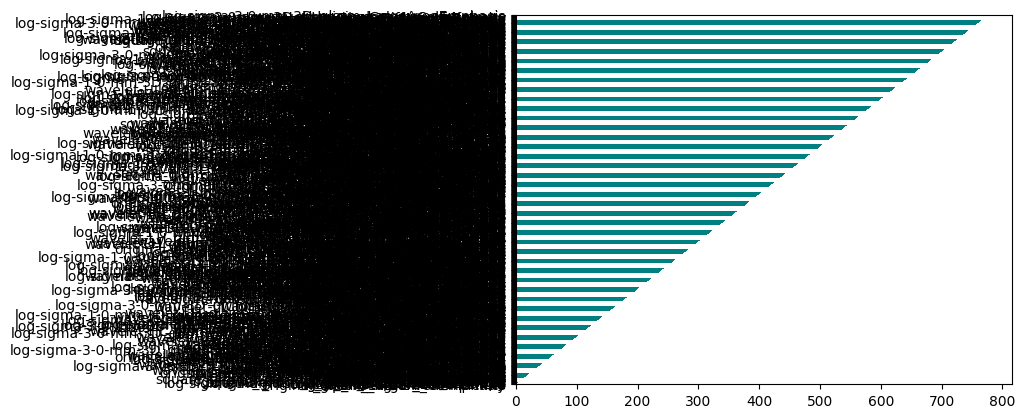

In [17]:
# pip install skfeature-chappers
# from skfeature.feat_selection import fisher_score
from skfeature.function.similarity_based import fisher_score
ranks = fisher_score.fisher_score(np.array(X),np.array(y))
feat_importance = pd.Series(ranks, X.columns[0:len(X.columns)])
fi = feat_importance.sort_values()
fi.plot(kind='barh',color = 'teal')


In [18]:
cols = ranks[ranks>0]
x_fs1= X.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_fs1.columns)

The features retained after using this techniques are :
Index(['original_firstorder_Energy', 'original_firstorder_Entropy',
       'original_firstorder_Uniformity',
       'original_glszm_GrayLevelNonUniformity',
       'original_glszm_SmallAreaLowGrayLevelEmphasis',
       'original_firstorder_RootMeanSquared', 'original_firstorder_Variance',
       'original_firstorder_InterquartileRange', 'original_firstorder_Mean',
       'original_firstorder_Range',
       ...
       'log-sigma-3-0-mm-3D_glszm_SizeZoneNonUniformity',
       'log-sigma-3-0-mm-3D_glcm_Contrast',
       'log-sigma-3-0-mm-3D_glszm_ZonePercentage',
       'square_gldm_GrayLevelNonUniformity', 'square_glcm_InverseVariance',
       'wavelet-HH_firstorder_TotalEnergy', 'wavelet-LH_firstorder_Skewness',
       'log-sigma-1-0-mm-3D_glszm_ZonePercentage',
       'log-sigma-1-0-mm-3D_glszm_LowGrayLevelZoneEmphasis',
       'log-sigma-3-0-mm-3D_glszm_LowGrayLevelZoneEmphasis'],
      dtype='object', length=777)


In [19]:
print("The shape of the reduced data is :",x_fs1.shape)

The shape of the reduced data is : (564, 777)


In [20]:
cols = ranks[ranks>=100]
x_fs2= X.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_fs2.columns)

The features retained after using this techniques are :
Index(['log-sigma-3-0-mm-3D_firstorder_Maximum',
       'wavelet-LL_glszm_SmallAreaEmphasis',
       'wavelet-LH_glszm_GrayLevelNonUniformityNormalized',
       'wavelet-HH_glszm_GrayLevelNonUniformityNormalized',
       'wavelet-HH_firstorder_Minimum',
       'log-sigma-3-0-mm-3D_firstorder_Kurtosis',
       'wavelet-HL_firstorder_Minimum',
       'wavelet-LH_gldm_DependenceNonUniformity',
       'log-sigma-3-0-mm-3D_firstorder_Energy',
       'wavelet-LH_glrlm_GrayLevelVariance',
       ...
       'log-sigma-3-0-mm-3D_glszm_SizeZoneNonUniformity',
       'log-sigma-3-0-mm-3D_glcm_Contrast',
       'log-sigma-3-0-mm-3D_glszm_ZonePercentage',
       'square_gldm_GrayLevelNonUniformity', 'square_glcm_InverseVariance',
       'wavelet-HH_firstorder_TotalEnergy', 'wavelet-LH_firstorder_Skewness',
       'log-sigma-1-0-mm-3D_glszm_ZonePercentage',
       'log-sigma-1-0-mm-3D_glszm_LowGrayLevelZoneEmphasis',
       'log-sigma-3-0-mm-3D

In [21]:
print("The shape of the reduced data is :",x_fs2.shape)

The shape of the reduced data is : (564, 678)


In [22]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_fs2.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0021 ± 0.0001
Score_time - Mean: 0.0166 ± 0.0004
Test_accuracy - Mean: 0.62 ± 0.01
Test_f1 - Mean: 0.75 ± 0.01
Test_roc_auc - Mean: 0.53 ± 0.04
Test_average_precision - Mean: 0.71 ± 0.04
Test_precision - Mean: 0.70 ± 0.03
Test_recall - Mean: 0.81 ± 0.03
AUPR: 0.74 ± 0.05


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.6980 ± 0.0288
Score_time - Mean: 0.0060 ± 0.0015
Test_accuracy - Mean: 0.69 ± 0.04
Test_f1 - Mean: 0.81 ± 0.03
Test_roc_auc - Mean: 0.59 ± 0.04
Test_average_precision - Mean: 0.76 ± 0.03
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.93 ± 0.02
AUPR: 0.76 ± 0.03
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0054 ± 0.0010
Score_time - Mean: 0.0054 ± 0.0005
Test_accuracy - Mean: 0.64 ± 0.08
Test_f1 - Mean: 0.74 ± 0.10
Test_roc_auc - Mean: 0.56 ± 0.01
Test_average_precision - Mean: 0.74 ± 0.03
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.80 ± 0.17
AUPR: 0.73 ± 0.03
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

In [23]:
cols = ranks[ranks>=200]
x_fs3= X.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_fs3.columns)

The features retained after using this techniques are :
Index(['log-sigma-3-0-mm-3D_firstorder_Maximum',
       'wavelet-LL_glszm_SmallAreaEmphasis',
       'wavelet-LH_glszm_GrayLevelNonUniformityNormalized',
       'wavelet-HH_glszm_GrayLevelNonUniformityNormalized',
       'wavelet-HH_firstorder_Minimum',
       'log-sigma-3-0-mm-3D_firstorder_Kurtosis',
       'wavelet-HL_firstorder_Minimum',
       'wavelet-LH_gldm_DependenceNonUniformity',
       'log-sigma-3-0-mm-3D_firstorder_Energy',
       'wavelet-LH_glrlm_GrayLevelVariance',
       ...
       'wavelet-LH_firstorder_RobustMeanAbsoluteDeviation',
       'log-sigma-1-0-mm-3D_glszm_ZoneVariance',
       'log-sigma-3-0-mm-3D_glszm_SizeZoneNonUniformity',
       'log-sigma-3-0-mm-3D_glcm_Contrast',
       'log-sigma-3-0-mm-3D_glszm_ZonePercentage',
       'wavelet-HH_firstorder_TotalEnergy', 'wavelet-LH_firstorder_Skewness',
       'log-sigma-1-0-mm-3D_glszm_ZonePercentage',
       'log-sigma-1-0-mm-3D_glszm_LowGrayLevelZoneEmpha

In [24]:
print("The shape of the reduced data is :",x_fs3.shape)

The shape of the reduced data is : (564, 578)


In [25]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_fs3.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0014 ± 0.0005
Score_time - Mean: 0.0194 ± 0.0020
Test_accuracy - Mean: 0.62 ± 0.01
Test_f1 - Mean: 0.75 ± 0.02
Test_roc_auc - Mean: 0.53 ± 0.04
Test_average_precision - Mean: 0.71 ± 0.04
Test_precision - Mean: 0.69 ± 0.03
Test_recall - Mean: 0.82 ± 0.04
AUPR: 0.74 ± 0.05


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.6654 ± 0.0197
Score_time - Mean: 0.0061 ± 0.0017
Test_accuracy - Mean: 0.69 ± 0.04
Test_f1 - Mean: 0.81 ± 0.03
Test_roc_auc - Mean: 0.60 ± 0.04
Test_average_precision - Mean: 0.78 ± 0.05
Test_precision - Mean: 0.71 ± 0.05
Test_recall - Mean: 0.93 ± 0.02
AUPR: 0.77 ± 0.05
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0041 ± 0.0000
Score_time - Mean: 0.0051 ± 0.0000
Test_accuracy - Mean: 0.62 ± 0.05
Test_f1 - Mean: 0.71 ± 0.07
Test_roc_auc - Mean: 0.56 ± 0.01
Test_average_precision - Mean: 0.74 ± 0.03
Test_precision - Mean: 0.73 ± 0.03
Test_recall - Mean: 0.71 ± 0.13
AUPR: 0.73 ± 0.03
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

In [26]:
cols = ranks[ranks>=300]
x_fs4= X.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_fs4.columns)

The features retained after using this techniques are :
Index(['wavelet-LL_glszm_SmallAreaEmphasis',
       'wavelet-LH_glszm_GrayLevelNonUniformityNormalized',
       'wavelet-HH_glszm_GrayLevelNonUniformityNormalized',
       'wavelet-HH_firstorder_Minimum', 'wavelet-HL_firstorder_Minimum',
       'wavelet-LH_gldm_DependenceNonUniformity',
       'wavelet-LH_glrlm_GrayLevelVariance',
       'wavelet-LH_glrlm_ShortRunLowGrayLevelEmphasis',
       'wavelet-LH_firstorder_Minimum',
       'wavelet-HL_glszm_GrayLevelNonUniformityNormalized',
       ...
       'log-sigma-3-0-mm-3D_glszm_ZoneVariance',
       'wavelet-LH_firstorder_Entropy',
       'log-sigma-3-0-mm-3D_glcm_DifferenceVariance',
       'wavelet-LH_firstorder_RobustMeanAbsoluteDeviation',
       'log-sigma-3-0-mm-3D_glszm_SizeZoneNonUniformity',
       'log-sigma-3-0-mm-3D_glcm_Contrast',
       'log-sigma-3-0-mm-3D_glszm_ZonePercentage',
       'wavelet-HH_firstorder_TotalEnergy', 'wavelet-LH_firstorder_Skewness',
       'lo

In [27]:
print("The shape of the reduced data is :",x_fs4.shape)

The shape of the reduced data is : (564, 478)


In [28]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_fs4.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0014 ± 0.0005
Score_time - Mean: 0.0165 ± 0.0008
Test_accuracy - Mean: 0.62 ± 0.01
Test_f1 - Mean: 0.75 ± 0.02
Test_roc_auc - Mean: 0.53 ± 0.03
Test_average_precision - Mean: 0.71 ± 0.04
Test_precision - Mean: 0.69 ± 0.03
Test_recall - Mean: 0.81 ± 0.04
AUPR: 0.73 ± 0.05


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.6653 ± 0.0060
Score_time - Mean: 0.0457 ± 0.0790
Test_accuracy - Mean: 0.70 ± 0.04
Test_f1 - Mean: 0.82 ± 0.03
Test_roc_auc - Mean: 0.59 ± 0.04
Test_average_precision - Mean: 0.77 ± 0.05
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.96 ± 0.02
AUPR: 0.76 ± 0.05
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0047 ± 0.0013
Score_time - Mean: 0.0047 ± 0.0018
Test_accuracy - Mean: 0.62 ± 0.05
Test_f1 - Mean: 0.72 ± 0.07
Test_roc_auc - Mean: 0.56 ± 0.02
Test_average_precision - Mean: 0.73 ± 0.03
Test_precision - Mean: 0.72 ± 0.04
Test_recall - Mean: 0.73 ± 0.13
AUPR: 0.73 ± 0.03
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

In [29]:
cols = ranks[ranks>=400]
x_fs5= X.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_fs5.columns)

The features retained after using this techniques are :
Index(['wavelet-LL_glszm_SmallAreaEmphasis',
       'wavelet-HH_glszm_GrayLevelNonUniformityNormalized',
       'wavelet-HH_firstorder_Minimum', 'wavelet-HL_firstorder_Minimum',
       'wavelet-LH_gldm_DependenceNonUniformity',
       'wavelet-LH_glrlm_GrayLevelVariance',
       'wavelet-LH_glrlm_ShortRunLowGrayLevelEmphasis',
       'wavelet-HL_glszm_GrayLevelNonUniformityNormalized',
       'wavelet-LL_glszm_GrayLevelNonUniformityNormalized',
       'wavelet-HL_glszm_ZoneVariance',
       ...
       'wavelet-HH_firstorder_Median', 'wavelet-HH_glcm_InverseVariance',
       'Hemoglobin', 'wavelet-LH_glcm_JointAverage',
       'wavelet-HH_firstorder_MeanAbsoluteDeviation',
       'Paedriatic_Appendicitis_Score',
       'wavelet-LL_glszm_LargeAreaLowGrayLevelEmphasis',
       'wavelet-LH_glcm_DifferenceVariance',
       'wavelet-HH_firstorder_RootMeanSquared',
       'wavelet-HH_firstorder_TotalEnergy'],
      dtype='object', length

In [30]:
print("The shape of the reduced data is :",x_fs5.shape)

The shape of the reduced data is : (564, 378)


In [31]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_fs5.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0008 ± 0.0004
Score_time - Mean: 0.0176 ± 0.0015
Test_accuracy - Mean: 0.63 ± 0.02
Test_f1 - Mean: 0.75 ± 0.01
Test_roc_auc - Mean: 0.53 ± 0.05
Test_average_precision - Mean: 0.71 ± 0.04
Test_precision - Mean: 0.70 ± 0.03
Test_recall - Mean: 0.82 ± 0.04
AUPR: 0.73 ± 0.05


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.6341 ± 0.0112
Score_time - Mean: 0.0051 ± 0.0000
Test_accuracy - Mean: 0.69 ± 0.04
Test_f1 - Mean: 0.81 ± 0.03
Test_roc_auc - Mean: 0.57 ± 0.04
Test_average_precision - Mean: 0.76 ± 0.05
Test_precision - Mean: 0.70 ± 0.04
Test_recall - Mean: 0.96 ± 0.02
AUPR: 0.75 ± 0.05
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0035 ± 0.0015
Score_time - Mean: 0.0074 ± 0.0036
Test_accuracy - Mean: 0.59 ± 0.07
Test_f1 - Mean: 0.69 ± 0.10
Test_roc_auc - Mean: 0.54 ± 0.02
Test_average_precision - Mean: 0.73 ± 0.04
Test_precision - Mean: 0.70 ± 0.04
Test_recall - Mean: 0.70 ± 0.17
AUPR: 0.72 ± 0.04
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

In [32]:
cols = ranks[ranks>=500]
x_fs6= X.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_fs6.columns)

The features retained after using this techniques are :
Index(['wavelet-LL_glszm_SmallAreaEmphasis',
       'wavelet-HH_glszm_GrayLevelNonUniformityNormalized',
       'wavelet-HH_firstorder_Minimum',
       'wavelet-LL_glszm_GrayLevelNonUniformityNormalized',
       'wavelet-HH_glcm_Contrast', 'wavelet-HH_glcm_ClusterProminence',
       'wavelet-HH_ngtdm_Coarseness', 'wavelet-HL_glcm_Id',
       'wavelet-LL_glrlm_RunVariance', 'wavelet-HH_glszm_SmallAreaEmphasis',
       ...
       'wavelet-HH_firstorder_90Percentile',
       'wavelet-LL_firstorder_InterquartileRange',
       'wavelet-HH_firstorder_Median', 'wavelet-HH_glcm_InverseVariance',
       'Hemoglobin', 'wavelet-HH_firstorder_MeanAbsoluteDeviation',
       'Paedriatic_Appendicitis_Score',
       'wavelet-LL_glszm_LargeAreaLowGrayLevelEmphasis',
       'wavelet-HH_firstorder_RootMeanSquared',
       'wavelet-HH_firstorder_TotalEnergy'],
      dtype='object', length=278)


In [33]:
print("The shape of the reduced data is :",x_fs6.shape)

The shape of the reduced data is : (564, 278)


In [34]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_fs6.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0008 ± 0.0004
Score_time - Mean: 0.0154 ± 0.0006
Test_accuracy - Mean: 0.62 ± 0.03
Test_f1 - Mean: 0.75 ± 0.02
Test_roc_auc - Mean: 0.54 ± 0.04
Test_average_precision - Mean: 0.72 ± 0.05
Test_precision - Mean: 0.69 ± 0.04
Test_recall - Mean: 0.82 ± 0.02
AUPR: 0.75 ± 0.05


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.6189 ± 0.0039
Score_time - Mean: 0.0049 ± 0.0004
Test_accuracy - Mean: 0.68 ± 0.03
Test_f1 - Mean: 0.81 ± 0.02
Test_roc_auc - Mean: 0.56 ± 0.05
Test_average_precision - Mean: 0.76 ± 0.06
Test_precision - Mean: 0.69 ± 0.04
Test_recall - Mean: 0.97 ± 0.01
AUPR: 0.75 ± 0.06
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0019 ± 0.0008
Score_time - Mean: 0.0086 ± 0.0049
Test_accuracy - Mean: 0.57 ± 0.09
Test_f1 - Mean: 0.65 ± 0.14
Test_roc_auc - Mean: 0.54 ± 0.03
Test_average_precision - Mean: 0.74 ± 0.04
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.64 ± 0.23
AUPR: 0.73 ± 0.04
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

In [35]:
cols = ranks[ranks>=600]
x_fs7= X.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_fs7.columns)

The features retained after using this techniques are :
Index(['wavelet-LL_glszm_SmallAreaEmphasis',
       'wavelet-LL_glszm_GrayLevelNonUniformityNormalized',
       'wavelet-HH_glcm_Contrast', 'wavelet-HH_glcm_ClusterProminence',
       'wavelet-HH_ngtdm_Coarseness', 'wavelet-LL_glrlm_RunVariance',
       'wavelet-LL_firstorder_Minimum', 'wavelet-LL_firstorder_10Percentile',
       'wavelet-LL_firstorder_Range', 'wavelet-LL_firstorder_Uniformity',
       ...
       'Loss_of_Appetite',
       'wavelet-LL_gldm_LargeDependenceLowGrayLevelEmphasis',
       'wavelet-LL_glrlm_ShortRunLowGrayLevelEmphasis', 'WBC_in_Urine',
       'Ipsilateral_Rebound_Tenderness',
       'wavelet-LL_firstorder_InterquartileRange',
       'wavelet-HH_glcm_InverseVariance', 'Hemoglobin',
       'Paedriatic_Appendicitis_Score',
       'wavelet-LL_glszm_LargeAreaLowGrayLevelEmphasis'],
      dtype='object', length=178)


In [36]:
print("The shape of the reduced data is :",x_fs7.shape)

The shape of the reduced data is : (564, 178)


In [37]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_fs4.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0012 ± 0.0004
Score_time - Mean: 0.0178 ± 0.0020
Test_accuracy - Mean: 0.62 ± 0.01
Test_f1 - Mean: 0.75 ± 0.02
Test_roc_auc - Mean: 0.53 ± 0.03
Test_average_precision - Mean: 0.71 ± 0.04
Test_precision - Mean: 0.69 ± 0.03
Test_recall - Mean: 0.81 ± 0.04
AUPR: 0.73 ± 0.05


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.6511 ± 0.0164
Score_time - Mean: 0.0054 ± 0.0004
Test_accuracy - Mean: 0.70 ± 0.04
Test_f1 - Mean: 0.82 ± 0.03
Test_roc_auc - Mean: 0.59 ± 0.04
Test_average_precision - Mean: 0.77 ± 0.05
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.96 ± 0.02
AUPR: 0.76 ± 0.05
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0043 ± 0.0020
Score_time - Mean: 0.0058 ± 0.0023
Test_accuracy - Mean: 0.62 ± 0.05
Test_f1 - Mean: 0.72 ± 0.07
Test_roc_auc - Mean: 0.56 ± 0.02
Test_average_precision - Mean: 0.73 ± 0.03
Test_precision - Mean: 0.72 ± 0.04
Test_recall - Mean: 0.73 ± 0.13
AUPR: 0.73 ± 0.03
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

## Applying Variance Threshold (ANOVA) as a Feature Selection technique:

In [38]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.2) #here threhold is 0.2
X_vt2 = v_threshold.fit_transform(X)
X_vt2.shape

mask = v_threshold.get_support(indices=True)
selected_cols = X.loc[:,X.columns[mask]]
selected_cols.columns

Index(['original_firstorder_10Percentile', 'original_firstorder_90Percentile',
       'original_firstorder_Energy', 'original_firstorder_InterquartileRange',
       'original_firstorder_Kurtosis', 'original_firstorder_Maximum',
       'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean',
       'original_firstorder_Median', 'original_firstorder_Minimum',
       ...
       'Neutrophilia', 'Hemoglobin', 'RDW', 'Thrombocyte_Count',
       'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Height',
       'Weight'],
      dtype='object', length=415)

In [39]:
print("The size of the reduced dataset is : ",X_vt2.shape)

The size of the reduced dataset is :  (564, 415)


In [40]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = X_vt2
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0010 ± 0.0000
Score_time - Mean: 0.0145 ± 0.0008
Test_accuracy - Mean: 0.62 ± 0.02
Test_f1 - Mean: 0.74 ± 0.02
Test_roc_auc - Mean: 0.53 ± 0.03
Test_average_precision - Mean: 0.71 ± 0.04
Test_precision - Mean: 0.69 ± 0.03
Test_recall - Mean: 0.81 ± 0.04
AUPR: 0.73 ± 0.05


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.6298 ± 0.0148
Score_time - Mean: 0.0053 ± 0.0004
Test_accuracy - Mean: 0.69 ± 0.04
Test_f1 - Mean: 0.81 ± 0.03
Test_roc_auc - Mean: 0.59 ± 0.04
Test_average_precision - Mean: 0.76 ± 0.03
Test_precision - Mean: 0.72 ± 0.04
Test_recall - Mean: 0.93 ± 0.01
AUPR: 0.76 ± 0.03
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0038 ± 0.0018
Score_time - Mean: 0.0065 ± 0.0024
Test_accuracy - Mean: 0.63 ± 0.08
Test_f1 - Mean: 0.73 ± 0.12
Test_roc_auc - Mean: 0.55 ± 0.02
Test_average_precision - Mean: 0.73 ± 0.02
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.78 ± 0.19
AUPR: 0.72 ± 0.02
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

In [41]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.4) #here threhold is 0.4
X_vt4 = v_threshold.fit_transform(X)
X_vt4.shape

mask = v_threshold.get_support(indices=True)
selected_cols = X.loc[:,X.columns[mask]]
selected_cols.columns

Index(['original_firstorder_10Percentile', 'original_firstorder_90Percentile',
       'original_firstorder_Energy', 'original_firstorder_InterquartileRange',
       'original_firstorder_Kurtosis', 'original_firstorder_Maximum',
       'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean',
       'original_firstorder_Median', 'original_firstorder_Minimum',
       ...
       'WBC_Count', 'Neutrophil_Percentage', 'Hemoglobin', 'RDW',
       'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'CRP',
       'Height', 'Weight'],
      dtype='object', length=386)

In [42]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = X_vt4
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0010 ± 0.0000
Score_time - Mean: 0.0159 ± 0.0005
Test_accuracy - Mean: 0.62 ± 0.02
Test_f1 - Mean: 0.74 ± 0.02
Test_roc_auc - Mean: 0.53 ± 0.03
Test_average_precision - Mean: 0.71 ± 0.04
Test_precision - Mean: 0.69 ± 0.03
Test_recall - Mean: 0.81 ± 0.04
AUPR: 0.73 ± 0.05


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.6172 ± 0.0095
Score_time - Mean: 0.0049 ± 0.0004
Test_accuracy - Mean: 0.68 ± 0.03
Test_f1 - Mean: 0.80 ± 0.02
Test_roc_auc - Mean: 0.59 ± 0.04
Test_average_precision - Mean: 0.77 ± 0.03
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.92 ± 0.02
AUPR: 0.77 ± 0.03
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0033 ± 0.0012
Score_time - Mean: 0.0078 ± 0.0045
Test_accuracy - Mean: 0.63 ± 0.08
Test_f1 - Mean: 0.73 ± 0.12
Test_roc_auc - Mean: 0.55 ± 0.02
Test_average_precision - Mean: 0.73 ± 0.02
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.78 ± 0.19
AUPR: 0.72 ± 0.02
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

## Applying Information gain as a feature selection technique:

BMI                                      0.480713
Age                                      0.440750
WBC_Count                                0.407763
Thrombocyte_Count                        0.384375
Neutrophil_Percentage                    0.372918
                                           ...   
log-sigma-3-0-mm-3D_glcm_JointAverage    0.000000
original_glcm_DifferenceEntropy          0.000000
original_glcm_DifferenceVariance         0.000000
log-sigma-3-0-mm-3D_glcm_ClusterShade    0.000000
wavelet-LH_firstorder_Variance           0.000000
Length: 778, dtype: float64

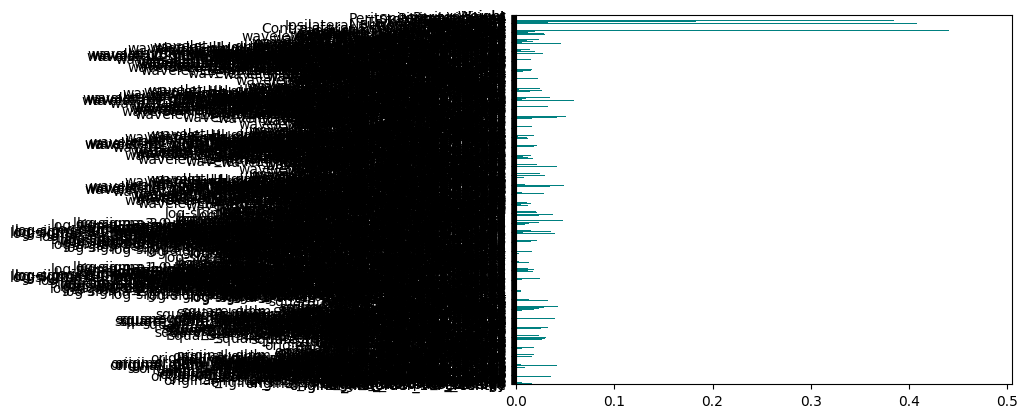

In [43]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(X,y,random_state=0)
feat_importance = pd.Series(importance, X.columns[0:len(X.columns)])
feat_importance.plot(kind='barh',color = 'teal')


mutual_info = pd.Series(importance)
mutual_info.index = X.columns
mutual_info.sort_values(ascending=False)


In [44]:
cols = mutual_info[mutual_info>0].index
cols
x_ig1 = X.loc[:,cols]

In [45]:
print("The shape of the reduced datset is",x_ig1.shape)

The shape of the reduced datset is (564, 517)


In [46]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_ig1.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0017 ± 0.0005
Score_time - Mean: 0.0211 ± 0.0010
Test_accuracy - Mean: 0.66 ± 0.03
Test_f1 - Mean: 0.77 ± 0.02
Test_roc_auc - Mean: 0.59 ± 0.04
Test_average_precision - Mean: 0.74 ± 0.05
Test_precision - Mean: 0.71 ± 0.03
Test_recall - Mean: 0.84 ± 0.03
AUPR: 0.76 ± 0.06


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.3813 ± 0.0010
Score_time - Mean: 0.0063 ± 0.0004
Test_accuracy - Mean: 0.69 ± 0.05
Test_f1 - Mean: 0.81 ± 0.03
Test_roc_auc - Mean: 0.57 ± 0.04
Test_average_precision - Mean: 0.74 ± 0.04
Test_precision - Mean: 0.71 ± 0.05
Test_recall - Mean: 0.95 ± 0.02
AUPR: 0.73 ± 0.04
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0036 ± 0.0005
Score_time - Mean: 0.0055 ± 0.0005
Test_accuracy - Mean: 0.63 ± 0.05
Test_f1 - Mean: 0.74 ± 0.07
Test_roc_auc - Mean: 0.56 ± 0.03
Test_average_precision - Mean: 0.74 ± 0.03
Test_precision - Mean: 0.71 ± 0.03
Test_recall - Mean: 0.78 ± 0.14
AUPR: 0.73 ± 0.04
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

In [47]:
cols = mutual_info[mutual_info>0.01].index
cols
x_ig2 = X.loc[:,cols]

In [48]:
print("The shape of the reduced datset is",x_ig2.shape)

The shape of the reduced datset is (564, 380)


In [49]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_ig2.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0008 ± 0.0004
Score_time - Mean: 0.0145 ± 0.0004
Test_accuracy - Mean: 0.65 ± 0.01
Test_f1 - Mean: 0.77 ± 0.01
Test_roc_auc - Mean: 0.61 ± 0.03
Test_average_precision - Mean: 0.76 ± 0.02
Test_precision - Mean: 0.71 ± 0.03
Test_recall - Mean: 0.84 ± 0.06
AUPR: 0.79 ± 0.02


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.5835 ± 0.0080
Score_time - Mean: 0.0049 ± 0.0004
Test_accuracy - Mean: 0.68 ± 0.05
Test_f1 - Mean: 0.80 ± 0.03
Test_roc_auc - Mean: 0.59 ± 0.06
Test_average_precision - Mean: 0.75 ± 0.04
Test_precision - Mean: 0.70 ± 0.05
Test_recall - Mean: 0.94 ± 0.02
AUPR: 0.74 ± 0.04
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0031 ± 0.0016
Score_time - Mean: 0.0078 ± 0.0040
Test_accuracy - Mean: 0.66 ± 0.02
Test_f1 - Mean: 0.77 ± 0.03
Test_roc_auc - Mean: 0.56 ± 0.04
Test_average_precision - Mean: 0.73 ± 0.02
Test_precision - Mean: 0.72 ± 0.03
Test_recall - Mean: 0.83 ± 0.06
AUPR: 0.73 ± 0.02
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

In [50]:
cols = mutual_info[mutual_info>0.02].index
cols
x_ig3 = X.loc[:,cols]

In [51]:
print("The shape of the reduced datset is",x_ig3.shape)

The shape of the reduced datset is (564, 230)


In [52]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_ig3.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0006 ± 0.0005
Score_time - Mean: 0.0144 ± 0.0011
Test_accuracy - Mean: 0.63 ± 0.04
Test_f1 - Mean: 0.75 ± 0.03
Test_roc_auc - Mean: 0.55 ± 0.05
Test_average_precision - Mean: 0.73 ± 0.05
Test_precision - Mean: 0.70 ± 0.05
Test_recall - Mean: 0.82 ± 0.04
AUPR: 0.76 ± 0.04


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.6161 ± 0.0097
Score_time - Mean: 0.0064 ± 0.0035
Test_accuracy - Mean: 0.69 ± 0.05
Test_f1 - Mean: 0.80 ± 0.03
Test_roc_auc - Mean: 0.62 ± 0.05
Test_average_precision - Mean: 0.78 ± 0.04
Test_precision - Mean: 0.71 ± 0.05
Test_recall - Mean: 0.93 ± 0.02
AUPR: 0.78 ± 0.04
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0018 ± 0.0004
Score_time - Mean: 0.0081 ± 0.0050
Test_accuracy - Mean: 0.66 ± 0.03
Test_f1 - Mean: 0.78 ± 0.03
Test_roc_auc - Mean: 0.56 ± 0.05
Test_average_precision - Mean: 0.74 ± 0.05
Test_precision - Mean: 0.71 ± 0.03
Test_recall - Mean: 0.87 ± 0.05
AUPR: 0.73 ± 0.05
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

## Applying Boruta Algorithm as a Feature Selection Technique

In [53]:
# !pip install numpy1.21

In [54]:
df.shape

(564, 779)

Iteration: 	1 / 10
Confirmed: 	0
Tentative: 	778
Rejected: 	0
Iteration: 	2 / 10
Confirmed: 	0
Tentative: 	778
Rejected: 	0
Iteration: 	3 / 10
Confirmed: 	0
Tentative: 	778
Rejected: 	0
Iteration: 	4 / 10
Confirmed: 	0
Tentative: 	778
Rejected: 	0
Iteration: 	5 / 10
Confirmed: 	0
Tentative: 	778
Rejected: 	0
Iteration: 	6 / 10
Confirmed: 	0
Tentative: 	778
Rejected: 	0
Iteration: 	7 / 10
Confirmed: 	0
Tentative: 	778
Rejected: 	0
Iteration: 	8 / 10
Confirmed: 	0
Tentative: 	24
Rejected: 	754
Iteration: 	9 / 10
Confirmed: 	9
Tentative: 	15
Rejected: 	754


BorutaPy finished running.

Iteration: 	10 / 10
Confirmed: 	9
Tentative: 	6
Rejected: 	754

------Support and Ranking for each feature------
Doesn't pass the test:  original_firstorder_10Percentile  - Ranking:  708
Doesn't pass the test:  original_firstorder_90Percentile  - Ranking:  422
Doesn't pass the test:  original_firstorder_Energy  - Ranking:  499
Doesn't pass the test:  original_firstorder_Entropy  - Ranking:  46
Doesn't pass 

<Axes: >

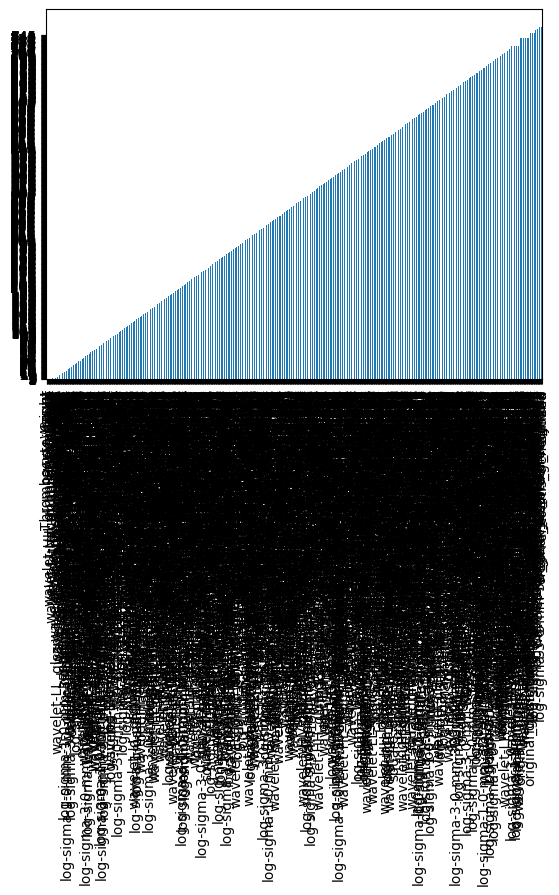

In [55]:
#Applying BORUTA algorithm

# from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import pandas as pd
import numpy as np

# # let's load the load_diabetes() dataset from sklearn
# X, y = load_diabetes(return_X_y=True, as_frame=True)

# let's initialize a RF model 
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
model.fit(X,y)

# let's initialize Boruta
feat_selector = BorutaPy(
    verbose=2,
    estimator=model,
    n_estimators='auto',
    max_iter=10  # number of iterations to perform
   
)

# train Boruta
# N.B.: X and y must be numpy arrays
feat_selector.fit(np.array(X), np.array(y))

# print support and ranking for each feature
print("\n------Support and Ranking for each feature------")
for i in range(len(feat_selector.support_)):
    if feat_selector.support_[i]:
        print("Passes the test: ", X.columns[i],
              " - Ranking: ", feat_selector.ranking_[i])
    else:
        print("Doesn't pass the test: ",
              X.columns[i], " - Ranking: ", feat_selector.ranking_[i])
        
        
        
sel_col = pd.Series(feat_selector.ranking_,index=X.columns)
sel_col.sort_values(inplace=True)

sel_col.plot(kind='bar',yticks=np.arange(746)) #It gives rank so aork accordingly

In [56]:
brt500 = sel_col[sel_col.values<=500]
brt500.index
cols = brt500.index
X_brt = X.loc[:,cols]
print("The shape of the reduced dataset is :",X_brt.shape)

The shape of the reduced dataset is : (564, 513)


In [57]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = X_brt.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0010 ± 0.0000
Score_time - Mean: 0.0177 ± 0.0008
Test_accuracy - Mean: 0.65 ± 0.02
Test_f1 - Mean: 0.77 ± 0.02
Test_roc_auc - Mean: 0.56 ± 0.03
Test_average_precision - Mean: 0.73 ± 0.04
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.84 ± 0.03
AUPR: 0.77 ± 0.04


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.6826 ± 0.0215
Score_time - Mean: 0.0066 ± 0.0037
Test_accuracy - Mean: 0.68 ± 0.04
Test_f1 - Mean: 0.80 ± 0.03
Test_roc_auc - Mean: 0.58 ± 0.03
Test_average_precision - Mean: 0.76 ± 0.03
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.93 ± 0.03
AUPR: 0.76 ± 0.03
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0038 ± 0.0012
Score_time - Mean: 0.0050 ± 0.0015
Test_accuracy - Mean: 0.64 ± 0.08
Test_f1 - Mean: 0.74 ± 0.10
Test_roc_auc - Mean: 0.56 ± 0.02
Test_average_precision - Mean: 0.74 ± 0.04
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.80 ± 0.16
AUPR: 0.74 ± 0.04
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

In [58]:
brt300 = sel_col[sel_col.values<=300]
brt300.index
cols = brt300.index
X_brt = X.loc[:,cols]
print("The shape of the reduced dataset is :",X_brt.shape)

The shape of the reduced dataset is : (564, 313)


In [59]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = X_brt.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [KNN, LOGREG,GNB, DT]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: KNeighborsClassifier()
Fit_time - Mean: 0.0008 ± 0.0004
Score_time - Mean: 0.0194 ± 0.0013
Test_accuracy - Mean: 0.64 ± 0.03
Test_f1 - Mean: 0.76 ± 0.02
Test_roc_auc - Mean: 0.58 ± 0.05
Test_average_precision - Mean: 0.74 ± 0.05
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.82 ± 0.05
AUPR: 0.77 ± 0.05


C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/mod

------------------------------------------------------------------------------------------------------




Classifier: LogisticRegression(max_iter=1000)
Fit_time - Mean: 0.6489 ± 0.0081
Score_time - Mean: 0.0050 ± 0.0009
Test_accuracy - Mean: 0.69 ± 0.03
Test_f1 - Mean: 0.81 ± 0.02
Test_roc_auc - Mean: 0.61 ± 0.03
Test_average_precision - Mean: 0.77 ± 0.03
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.94 ± 0.02
AUPR: 0.76 ± 0.03
------------------------------------------------------------------------------------------------------




Classifier: GaussianNB()
Fit_time - Mean: 0.0023 ± 0.0004
Score_time - Mean: 0.0053 ± 0.0015
Test_accuracy - Mean: 0.65 ± 0.05
Test_f1 - Mean: 0.77 ± 0.05
Test_roc_auc - Mean: 0.58 ± 0.02
Test_average_precision - Mean: 0.75 ± 0.03
Test_precision - Mean: 0.71 ± 0.04
Test_recall - Mean: 0.83 ± 0.08
AUPR: 0.74 ± 0.04
------------------------------------------------------------------------------------------------------




Classifier: DecisionTreeCl

## Using SHAP value as a Feature Selection technique:

In [60]:
model = DT

In [61]:
# !pip install shap
import shap
model.fit(x_train,y_train)
explainer = shap.Explainer(model.predict, x_test)
shap_values = explainer(x_test,max_evals=2000)

PermutationExplainer explainer: 114it [02:25,  1.34s/it]                                                               


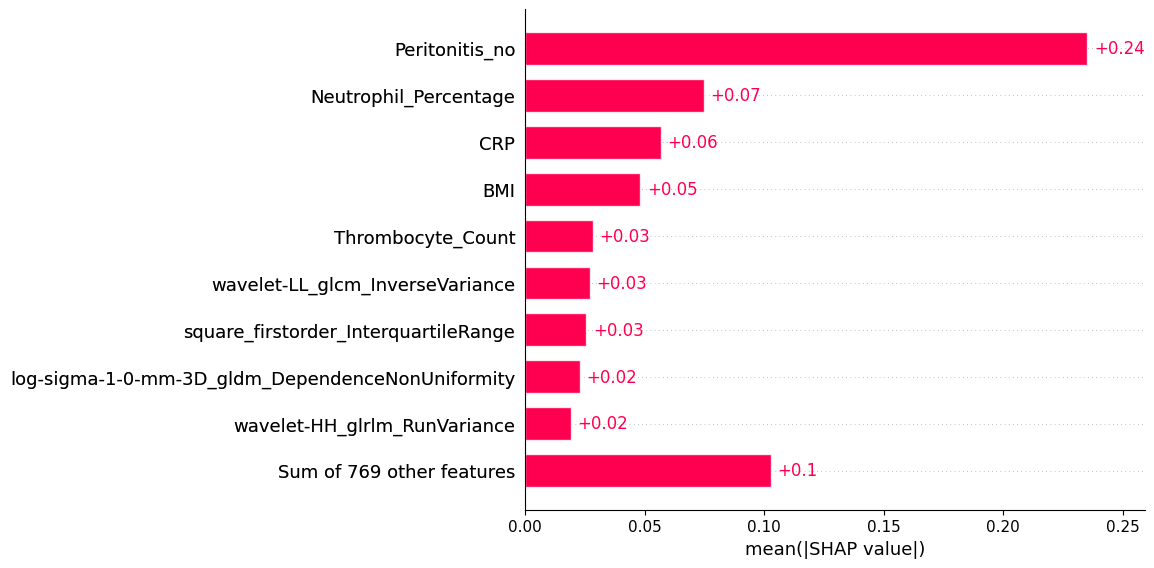

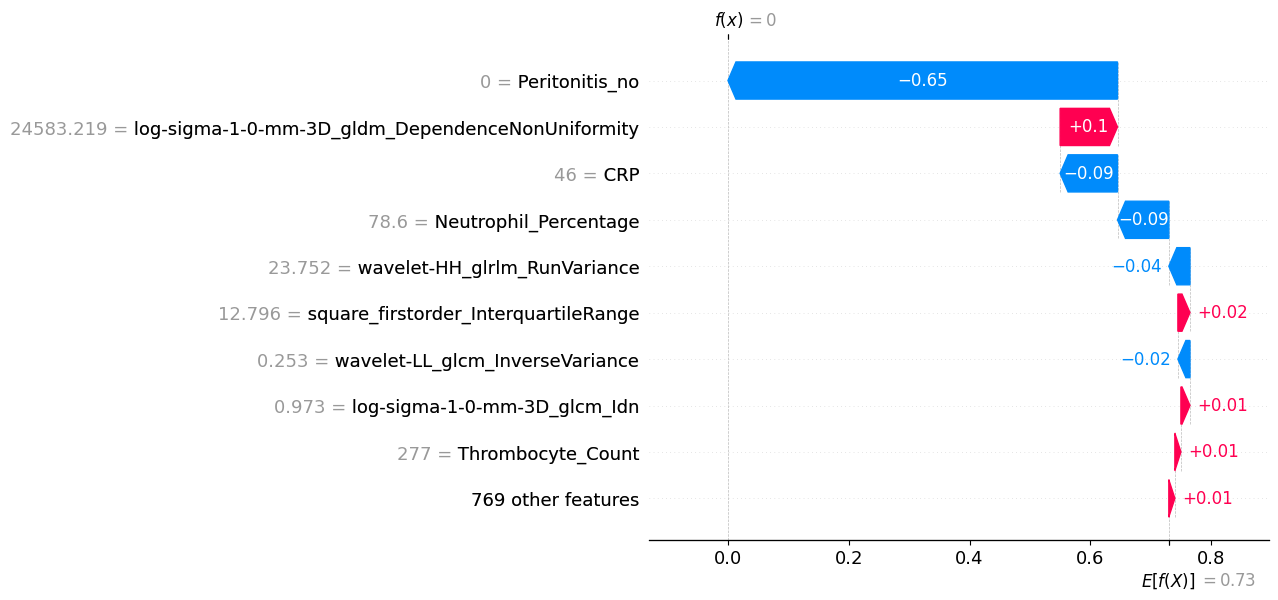

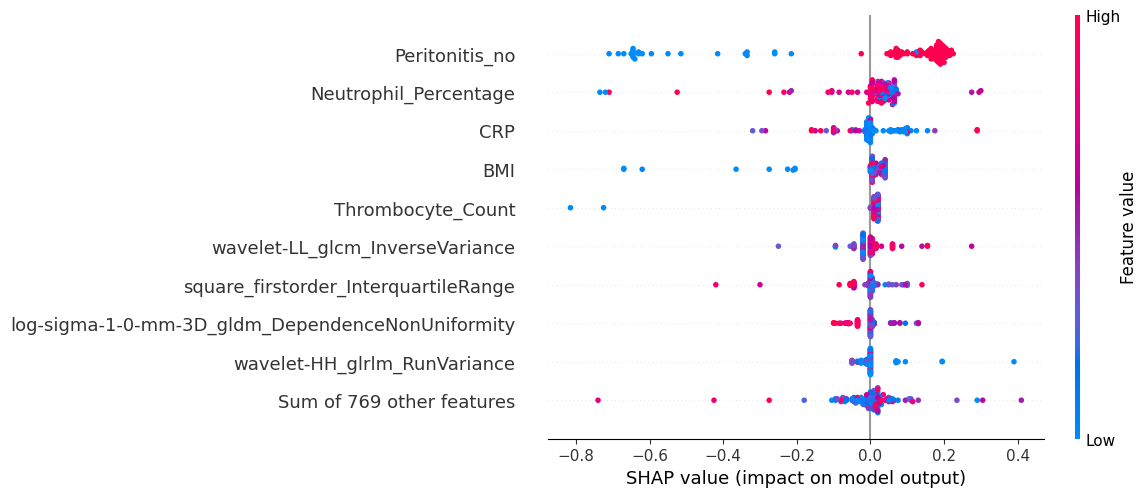

In [62]:
shap.plots.bar(shap_values)
shap.plots.waterfall(shap_values[0])
shap.plots.beeswarm(shap_values)

In [65]:
# cols = ["Appendix_Diameter","Alvarado_Score","Paedriatic_Appendicitis_Score","Thrombocyte_Count"]

In [66]:
# X_shap = X.loc[:,cols]
# print("The shape of the reduced dataset is :",X_shap.shape)

In [67]:
# # AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# # set model here
# model = KNN
# X1 = X_shap.values
# y1 = y.values

# def calculate_all(model, X1, y1, k=5):
#         kf = KFold(n_splits=k, shuffle=True, random_state=42)
#         aupr_scores = []

#         scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

#         for train_index, val_index in kf.split(X, y):
#             X_train, X_val = X1[train_index], X1[val_index]
#             y_train, y_val = y1[train_index], y1[val_index]

#             model.fit(X_train, y_train)
#             y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

#             precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
#             aupr = auc(recall, precision)
#             aupr_scores.append(aupr)

#         result = list()
#         scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

#         return scores, aupr_scores


# model_list = [KNN, LOGREG,GNB, DT]

# for model in model_list:
#     # invoking function

#     results = calculate_all(model, X1, y1)
#     scores = results[0]
#     aupr_list = results[1]

#     # mean and standard deviations over all folds
#     print("------------------------------------------------------------------------------------------------------")
#     print(f'\n\n\n\nClassifier: {model}' )

#     aupr_mean = np.mean(aupr_list)
#     aupr_std = np.std(aupr_list)

#     for value in scores:
#         v = str(value)
#         mean_score = scores[v].mean()
#         std_score = scores[v].std()
#         if (v == "fit_time" or v =="score_time"):
#             print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
#         else:
#             print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

#     print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

# Selecting the best / reduced dataset and applying Ensemble Techniques:

In [63]:
# Boosting Classifiers
# random forest
RF = RandomForestClassifier(
    n_estimators=100,    # Number of trees in the forest
    criterion='gini',    # Split criterion ('gini' or 'entropy')
    max_depth=None,      # Maximum depth of the tree
    min_samples_split=2, # Minimum number of samples required to split an internal node
    min_samples_leaf=1,  # Minimum number of samples required to be at a leaf node
#     max_features='auto', # Number of features to consider when looking for the best split
    random_state=42,     # Random state for reproducibility
    n_jobs=-1            # Number of jobs to run in parallel (-1 means using all processors)
)

# gradient boosting machine (GBM)
gbm_model = GradientBoostingClassifier(
    learning_rate=0.1,      # Learning rate or step size at which the model is updated. Typical values: [0.01, 0.05, 0.1].
    n_estimators=100,       # Number of boosting rounds (trees) to be used in the model. Typical values: [100, 200, 300].
    max_depth=6,            # Maximum depth of each tree. A higher value can lead to overfitting. Typical values: [3, 4, 5, 6].
    min_samples_split=2,    # Minimum number of samples required to split an internal node. Typical values: [2, 5, 10].
    min_samples_leaf=1,     # Minimum number of samples required to be at a leaf node. Typical values: [1, 2, 4].
    subsample=1.0,          # Subsample ratio of the training instance. Randomly selects a fraction of the data to grow trees. Typical values: [0.7, 0.8, 0.9].
    max_features=None,      # Number of features to consider when looking for the best split. Typical values: [None, 'sqrt', 'log2'].
    max_leaf_nodes=None,    # Maximum number of leaves in each tree. Typical values: [None, 10, 50, 100].
    random_state=42         # Seed for random number generator for reproducibility.
)


# light gradient boosting (lGBM)
LGBM = LGBMClassifier(verbose=-1)
    #learning_rate=0.1,      # Learning rate or step size at which the model is updated. Typical values: [0.01, 0.05, 0.1].
    #n_estimators=200,       # Number of boosting rounds (trees) to be used in the model. Typical values: [100, 200, 300].
    #max_depth=None,          # Maximum depth of each tree. A higher value can lead to overfitting. Typical values: [3, 4, 5, 6].
    #verbose=-1)


# xtreme gradient boosting (XGBoost)
XGB = XGBClassifier(objective='binary:logistic')

# categorical boosting (CatBoost)
CATBOOST = CatBoostClassifier(
    iterations=1500,          # Number of boosting iterations
    learning_rate=0.1,        # Learning rate for gradient boosting
    depth=6,                  # Depth of the trees
    loss_function='Logloss',  # Loss function to optimize
    eval_metric='Accuracy',   # Metric for evaluation
    random_seed=42)           # Random seed for reproducibility

# adaptive boosting (AdaBoost)
base_esti = LGBM # set to anything, tree based / normals / gbms

ADABOOST = AdaBoostClassifier(
    # base_estimator=base_esti,  # Base estimator to use for boosting
    n_estimators=200,               # Number of weak learners to train iteratively
    learning_rate=0.1,             # Learning rate (shrinks the contribution of each classifier)
    algorithm='SAMME',           # AdaBoost algorithm ('SAMME' or 'SAMME.R')
    random_state=42)               # Random state for reproducibility

In [64]:
# AUTOMATED CODE FOR ALL MECTRIC CHECK - set value of model and X,Y in model setter cell / Or here  (NEWEST)

# set model here
model = KNN
X1 = x_ig3.values
y1 = y.values

def calculate_all(model, X1, y1, k=5):
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        aupr_scores = []

        scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

        for train_index, val_index in kf.split(X, y):
            X_train, X_val = X1[train_index], X1[val_index]
            y_train, y_val = y1[train_index], y1[val_index]

            model.fit(X_train, y_train)
            y_val_pred_proba = model.predict_proba(X_val)[:, 1] # Assuming binary classification

            precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
            aupr = auc(recall, precision)
            aupr_scores.append(aupr)

        result = list()
        scores = cross_validate(model, X1, y1, cv=kf, scoring=scoring)

        return scores, aupr_scores


model_list = [RF, LGBM,XGB, ADABOOST]

for model in model_list:
    # invoking function

    results = calculate_all(model, X1, y1)
    scores = results[0]
    aupr_list = results[1]

    # mean and standard deviations over all folds
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )

    aupr_mean = np.mean(aupr_list)
    aupr_std = np.std(aupr_list)

    for value in scores:
        v = str(value)
        mean_score = scores[v].mean()
        std_score = scores[v].std()
        if (v == "fit_time" or v =="score_time"):
            print(f"{v.capitalize()} - Mean: {mean_score:.4f} ± {std_score:.4f}")
        else:
            print(f"{v.capitalize()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

    print(f"AUPR: {aupr_mean:.2f} ± {aupr_std:.2f}")

------------------------------------------------------------------------------------------------------




Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)
Fit_time - Mean: 0.1603 ± 0.0075
Score_time - Mean: 0.0431 ± 0.0010
Test_accuracy - Mean: 0.90 ± 0.03
Test_f1 - Mean: 0.93 ± 0.02
Test_roc_auc - Mean: 0.97 ± 0.01
Test_average_precision - Mean: 0.99 ± 0.01
Test_precision - Mean: 0.89 ± 0.04
Test_recall - Mean: 0.98 ± 0.02
AUPR: 0.99 ± 0.01
------------------------------------------------------------------------------------------------------




Classifier: LGBMClassifier(verbose=-1)
Fit_time - Mean: 0.1201 ± 0.0068
Score_time - Mean: 0.0069 ± 0.0007
Test_accuracy - Mean: 0.99 ± 0.00
Test_f1 - Mean: 0.99 ± 0.00
Test_roc_auc - Mean: 1.00 ± 0.00
Test_average_precision - Mean: 1.00 ± 0.00
Test_precision - Mean: 0.99 ± 0.01
Test_recall - Mean: 0.99 ± 0.01
AUPR: 1.00 ± 0.00
------------------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------------------




Classifier: RandomForestClassifier(n_jobs=-1, random_state=42)


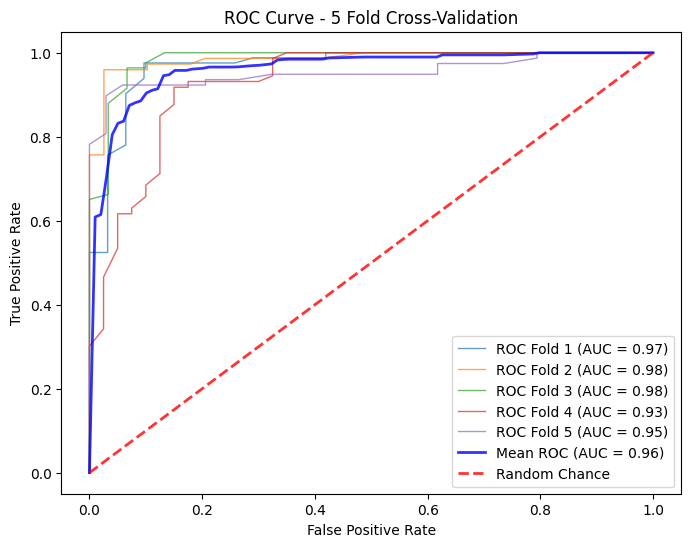

------------------------------------------------------------------------------------------------------




Classifier: LGBMClassifier(verbose=-1)


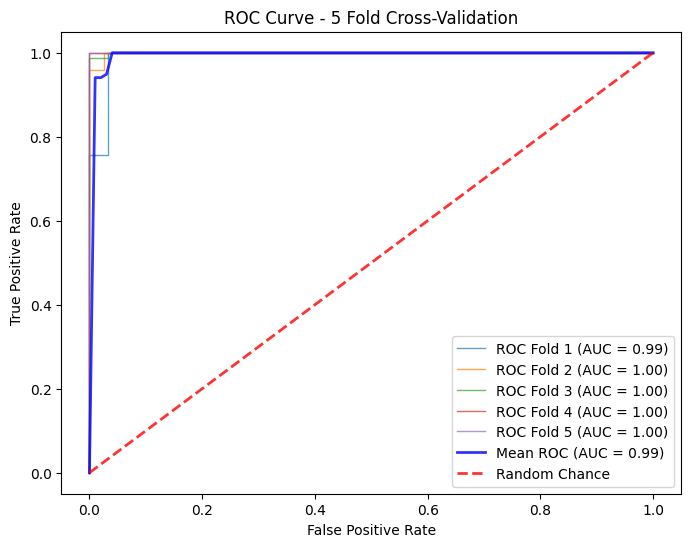

------------------------------------------------------------------------------------------------------




Classifier: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)


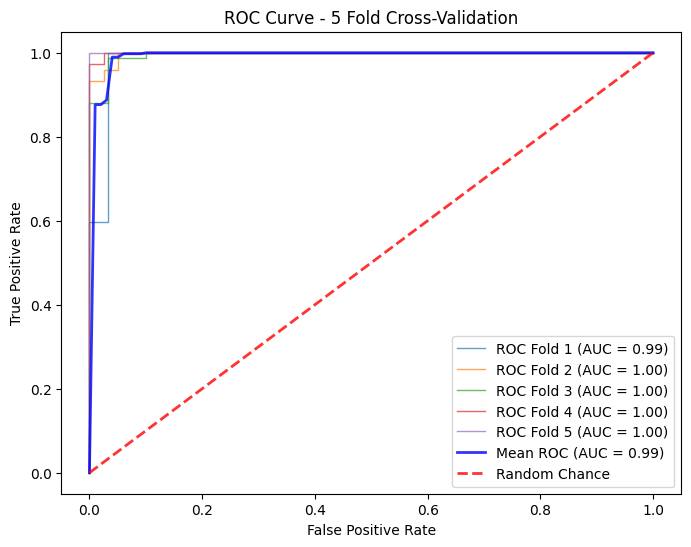

------------------------------------------------------------------------------------------------------




Classifier: AdaBoostClassifier(algorithm='SAMME', learning_rate=0.1, n_estimators=200,
                   random_state=42)


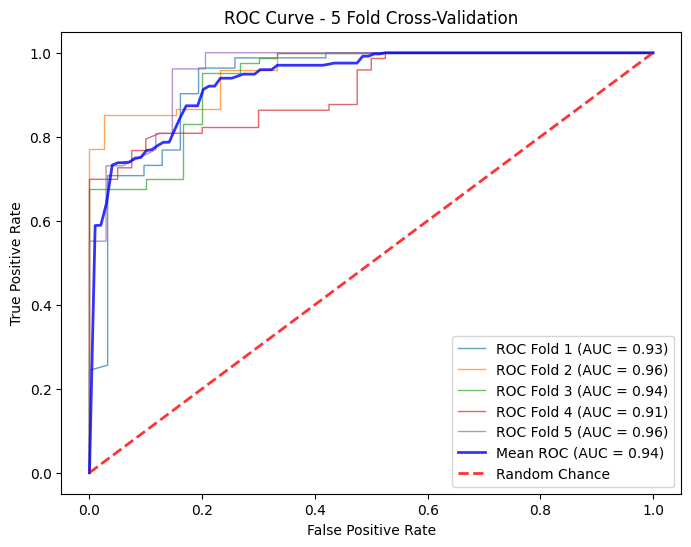

In [65]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

model_list = [RF, LGBM,XGB, ADABOOST]

for model in model_list:
    # Assuming you have your data and model ready
    X = x_ig2
    # X= pd.concat([x_train,x_test])
    # y= pd.concat([y_train,y_test])
    # y = your_labels  # Target variable

    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    plt.figure(figsize=(8, 6))
    print("------------------------------------------------------------------------------------------------------")
    print(f'\n\n\n\nClassifier: {model}' )
    # Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
    mean_tpr = 0.0
    mean_fpr = np.linspace(0, 1, 100)
    all_tpr = []

    for i, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, Y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Compute ROC curve and area under the curve
        fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve for this fold
        plt.plot(fpr, tpr, lw=1, alpha=0.7,
                 label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

        # Interpolate tpr at mean_fpr
        mean_tpr += np.interp(mean_fpr, fpr, tpr)
        mean_tpr[0] = 0.0

    # Calculate mean of tprs and auc across all folds
    mean_tpr /= kf.get_n_splits(X)
    mean_auc = auc(mean_fpr, mean_tpr)

    # Plot mean ROC curve
    plt.plot(mean_fpr, mean_tpr, color='b',
             label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

    # Plot the random chance line
    plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
             label='Random Chance', alpha=.8)

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - 5 Fold Cross-Validation')
    plt.legend(loc='lower right')
    plt.show()
